<div style="max-width:700px; margin: 30px auto; padding: 30px; border: 2px solid #4a90e2; border-radius: 12px; font-family: Arial, sans-serif; background: #f0f8ff;">
  <h2 style="text-align:center; color:#1a3e72; margin-bottom: 20px; font-size: 3em;">Grivan Newman Simulator (using Python)</h2>
  <h3 style="text-align:center; color:#3c6eaa; margin-top: 0; font-size: 2.4em; margin-bottom: 40px;">Assignment</h3>
  
  <table style="width: 100%; font-size: 22px; color: #2a2a2a; border-collapse: separate; border-spacing: 40px 25px;">
    <tbody>
      <tr>
        <td style="font-weight: 700; width: 35%;">Student Name:</td>
        <td style="width: 15%;">Aashnan Rahman</td>
        <td style="font-weight: 700; width: 35%;">Student ID:</td>
        <td style="width: 15%;">231041006</td>
      </tr>
      <tr>
        <td style="font-weight: 700;">Course Name:</td>
        <td>Big Data Analysis and Management</td>
        <td style="font-weight: 700;">Course Code:</td>
        <td>CSE 6279</td>
      </tr>
      <tr>
        <td style="font-weight: 700;">Date:</td>
        <td>August 18, 2025</td>
        <td style="font-weight: 700;">Semester:</td>
        <td>Summer 2023-2024</td>
      </tr>
    </tbody>
  </table>
</div>


<h1>Girvan Newman</h1>
The Girvan-Newman algorithm is a popular method for detecting communities within complex networks. It works by progressively removing edges that are most important for holding the network together, specifically those with the highest betweenness centrality, a measure of how often an edge lies on the shortest paths between pairs of nodes. By removing these critical edges, the network gradually breaks down into smaller, tightly-knit groups or communities. The algorithm repeats this process iteratively, recalculating betweenness after each removal, which helps reveal the natural modular structure of the network. It’s widely used in social network analysis, biology, and many other fields to identify clusters without prior knowledge of their number or size.

<h3>Instructions</h3>


Upload a file named `graph.txt` containing graph information. The first line should specify the number of nodes in the graph. The second line should contain a list of edges represented as tuples, for example:
<pre>
7
[(0,1),(0,2),(1,2),(1,3),(3,4),(3,5),(3,6),(4,5),(5,6)]
</pre>

<h1>Libraries</h1>

In [ ]:
import networkx as nx
from networkx.algorithms.community import girvan_newman
from networkx.drawing.nx_agraph import graphviz_layout
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict, deque
from IPython.display import clear_output, display
import time
import pandas as pd
import numpy as np
from PIL import Image
import io

<h1>Helper Functions</h1>

> The `read_graph_from_file` function reads an undirected graph from a file. The file should contain the number of nodes on the first line and a list of edge tuples on the second. It builds and returns the graph as an adjacency list using a dictionary where each node maps to a set of its connected neighbors.

In [ ]:
def read_graph_from_file(filename):
    with open(filename, 'r') as f:
        num_nodes = int(f.readline().strip())
        edge_line = f.readline().strip()
        edges = eval(edge_line)

    graph = {i: set() for i in range(num_nodes)}
    for u, v in edges:
        graph[u].add(v)

        graph[v].add(u)

    return graph

> The `init_table` function creates a DataFrame to represent edge-related data for a given undirected graph. It extracts all unique edges from the graph dictionary, sorts them, and uses them as row labels. Columns include all node labels, plus two extra columns: `sum` and `sum_by_half`. The DataFrame is initialized with `NaN` values and returned for later use in storing edge-based computations.


In [ ]:
def init_table(graph_dict):

    all_edges = set()
    for node, neighbors in graph_dict.items():
        for nbr in neighbors:
            edge = tuple(sorted((node, nbr)))
            all_edges.add(edge)

    all_edges = sorted(all_edges)
    all_nodes = sorted(graph_dict.keys())

    columns = all_nodes + ['sum', 'sum_by_half']

    df = pd.DataFrame(index=[f"{u}–{v}" for u, v in all_edges], columns=columns)

    df[:] = np.nan

    return df

> The `figure_to_image` function converts a Matplotlib figure into a PIL image. It saves the figure to an in-memory buffer in PNG format, repositions the buffer to the start, and opens the image using PIL with an RGBA color mode. The resulting image object is returned, allowing further image processing or display without saving to disk.


In [ ]:
def figure_to_image(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img = Image.open(buf).convert("RGBA")
    buf.close()
    return img

> The `fill_edge_values` function populates a DataFrame with values associated with edges in a graph. For each `(u, v, val)` in `edge_values`, it identifies the corresponding edge row and assigns `val` under the column labeled by `root`. If the edge doesn't exist in the DataFrame index, it prints a warning. After filling values, it computes the row-wise sum across all numeric columns (excluding `'sum'` and `'sum_by_half'`) and stores the result in the `'sum'` column. It also calculates `'sum_by_half'` as half of that sum.


In [ ]:
def fill_edge_values(df, root, edge_values):
    for u, v, val in edge_values:
        edge = tuple(sorted((u, v)))
        edge_label = f"{edge[0]}–{edge[1]}"
        if edge_label in df.index:
            df.at[edge_label, root] = val
        else:
            print(f"Warning: edge {edge_label} not found in DataFrame index")

    numeric_cols = [col for col in df.columns if col not in ['sum', 'sum_by_half']]
    df['sum'] = df[numeric_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1)
    df['sum_by_half'] = df['sum'] / 2

> The `graph_to_networkx` function converts a graph represented as an adjacency list (dictionary) into a NetworkX `Graph` object. It iterates over each node and its neighbors, adding edges to the NetworkX graph. The resulting undirected graph `G` is returned for further analysis or visualization using NetworkX tools.


In [ ]:
def graph_to_networkx(graph_dict):
    G = nx.Graph()
    for node, neighbors in graph_dict.items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)
    return G

> The `visualize_graph` function displays a visual representation of a NetworkX graph `G` using Matplotlib. It uses a spring layout to position the nodes and customizes the appearance with labeled, light-blue nodes and gray edges. The function sets a title, adjusts the layout, and shows the graph in a Matplotlib window.


In [ ]:
def visualize_graph(G, title="Graph"):
    pos = nx.spring_layout(G)
    fig, ax = plt.subplots(figsize=(8, 6))

    nx.draw(
        G, pos,
        with_labels=True,
        node_color='lightblue',
        edge_color='gray',
        node_size=1200,
        linewidths=1.5,
        edgecolors='black',
        ax=ax
    )

    border = patches.Rectangle(
        (0, 0), 1, 1,
        transform=ax.transAxes,
        fill=False,
        color='black',
        linewidth=3
    )
    ax.add_patch(border)

    plt.title(title)
    plt.tight_layout()
    plt.show()

> The `get_bfs_levels` function performs a Breadth-First Search (BFS) on a graph starting from a given `root` node. It assigns each node a level based on its distance (in edges) from the root. The result is a dictionary mapping each node to its BFS level.


In [ ]:
def get_bfs_levels(graph, root):
    levels = {root: 0}
    visited = set([root])
    queue = deque([root])

    while queue:
        node = queue.popleft()
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                levels[neighbor] = levels[node] + 1
                queue.append(neighbor)
    return levels

> The `build_level_dag_with_props` function creates a directed acyclic graph (DAG) from an undirected graph based on BFS levels starting from a specified root. Edges are directed from lower-level nodes to higher-level nodes, ensuring a hierarchical structure. It initializes a `startoff` property for each node, setting the root's to 1 and others based on the sum of their parents' values. Additionally, it marks nodes as leaves if they have no outgoing edges and attaches both the `is_leaf` and `startoff` properties to each node in the DAG before returning it.


In [ ]:
def build_level_dag_with_props(graph, root):
    levels = get_bfs_levels(graph, root)
    dag = nx.DiGraph()

    for u in graph:
        for v in graph[u]:
            if levels.get(u, -1) < levels.get(v, -1):
                dag.add_edge(u, v)
            elif levels.get(v, -1) < levels.get(u, -1):
                dag.add_edge(v, u)

    startoff = {node: 0 for node in dag.nodes()}
    startoff[root] = 1

    nodes_by_level = sorted(dag.nodes(), key=lambda n: levels[n])

    for node in nodes_by_level:
        parents = list(dag.predecessors(node))
        if node != root:
            startoff[node] = sum(startoff[p] for p in parents)

    for node in dag.nodes():
        is_leaf = dag.out_degree(node) == 0
        dag.nodes[node]['is_leaf'] = is_leaf
        dag.nodes[node]['startoff'] = startoff[node]

    return dag

> The `bfs_level_layout` function generates a 2D layout for graph visualization based on BFS levels from a given root. It groups nodes by their distance from the root and arranges each level horizontally, evenly spacing nodes along the x-axis while stacking levels vertically with consistent y-axis spacing. The function returns a dictionary mapping each node to its `(x, y)` coordinates for plotting.


In [ ]:
def bfs_level_layout(graph, root, x_spacing=1.5, y_spacing=1.5):
    levels = get_bfs_levels(graph, root)

    # Group nodes by their level (depth)
    level_nodes = defaultdict(list)
    for node, depth in levels.items():
        level_nodes[depth].append(node)

    pos = {}
    for depth, nodes in level_nodes.items():
        num_nodes = len(nodes)
        x_start = -x_spacing * (num_nodes - 1) / 2  # center-align nodes
        for i, node in enumerate(sorted(nodes)):
            pos[node] = (x_start + i * x_spacing, -depth * y_spacing)

    return pos

>The `build_level_dag` function constructs a directed acyclic graph (DAG) from an undirected graph by directing edges from nodes at lower BFS levels to nodes at higher levels, starting from a specified root. This creates a hierarchy reflecting the distance of nodes from the root. The resulting DAG is returned for further use.


In [ ]:
def build_level_dag(graph, root):
    levels = get_bfs_levels(graph, root)
    dag = nx.DiGraph()

    for u in graph:
        for v in graph[u]:
            if levels.get(u, -1) < levels.get(v, -1):
                dag.add_edge(u, v)
            elif levels.get(v, -1) < levels.get(u, -1):
                dag.add_edge(v, u)
    return dag

>The `compute_edge_and_node_values` function calculates and assigns values to nodes and edges in a directed acyclic graph (DAG). Starting from the leaves and moving upward (using a reversed topological order), it computes edge values based on the `startoff` property and the node values of children. Leaf edges are assigned values differently than non-leaf edges. Node values are derived from the sum of their outgoing edge values plus one, normalized by their `startoff`. The function updates the DAG’s edge and node attributes with these computed values and returns both the updated DAG and a list of edge values.


In [ ]:
def compute_edge_and_node_values(dag):
    edge_values = []  # (node, child, edge_val)

    for u, v in dag.edges():
        dag.edges[u, v]['edge_value'] = None
        dag.edges[u, v]['edge_type'] = None
    for node in dag.nodes():
        dag.nodes[node]['node_value'] = None

    for node in list(nx.topological_sort(dag))[::-1]:
        startoff = dag.nodes[node]['startoff']
        out_edges = list(dag.out_edges(node))

        if not out_edges:  # Leaf node
            dag.nodes[node]['node_value'] = None
        else:
            sum_out_edge_vals = 0
            for _, child in out_edges:
                child_startoff = dag.nodes[child]['startoff']
                child_out_edges = list(dag.out_edges(child))

                if not child_out_edges:  # Leaf node
                    edge_val = dag.nodes[node]['startoff'] / child_startoff
                    dag.edges[node, child]['edge_type'] = 'leaf'
                else:
                    if dag.nodes[child]['node_value'] is None:
                        raise ValueError(f"Node value for child {child} not yet computed.")
                    edge_val = dag.nodes[child]['node_value']
                    dag.edges[node, child]['edge_type'] = 'non_leaf'

                dag.edges[node, child]['edge_value'] = edge_val
                sum_out_edge_vals += edge_val
                edge_values.append((node, child, edge_val))

            dag.nodes[node]['node_value'] = (1 + sum_out_edge_vals) / startoff

    return dag, edge_values

> The `visualize_dag` function visualizes a directed acyclic graph (DAG) with a layout based on BFS levels from a specified root. Nodes are colored with the root highlighted in orange. Node labels can optionally show the `startoff` value. Edge values are optionally displayed at the midpoint of edges, colored red for leaf edges and green for non-leaf edges. The graph is drawn with arrows to show direction, and a bold border is added around the plot. The function returns the Matplotlib figure object for further use or display.


In [ ]:
def visualize_dag(G, root, title=None, show_startoff=False, show_edge_value=False):
    pos = bfs_level_layout(G, root)

    node_colors = ['orange' if node == root else 'lightblue' for node in G.nodes()]

    if show_startoff:
        labels = {node: f"{node}\n({G.nodes[node].get('startoff', '')})" for node in G.nodes()}
    else:
        labels = {node: str(node) for node in G.nodes()}

    fig, ax = plt.subplots(figsize=(10, 7))
    nx.draw(
        G, pos,
        labels=labels,
        with_labels=True,
        node_color=node_colors,
        edge_color='gray',
        node_size=1200,
        linewidths=1.5,
        edgecolors='black',
        arrows=True,
        ax=ax
    )

    if show_edge_value:
        for (u, v) in G.edges():
            val = G.edges[u, v].get('edge_value')
            edge_type = G.edges[u, v].get('edge_type')
            if val is not None:
                mid_x = (pos[u][0] + pos[v][0]) / 2
                mid_y = (pos[u][1] + pos[v][1]) / 2
                color = 'red' if edge_type == 'leaf' else 'green'
                ax.text(mid_x, mid_y, f"{val:.2f}", color=color,
                        fontsize=10, ha='center', va='center',
                        bbox=dict(facecolor='white', edgecolor='none', pad=1.0))

    border = patches.Rectangle((0, 0), 1, 1,
                               transform=ax.transAxes,
                               fill=False,
                               color='black',
                               linewidth=3)
    ax.add_patch(border)

    if title is None:
        title = f"DAG with root {root}"
    plt.title(title)

    plt.tight_layout()
    return fig

> The `visualize_communities_by_edge_removal` function analyzes and visualizes communities in a graph formed by removing the strongest edges based on their `sum_by_half` values. It builds an undirected graph from edge labels, removes the top `num_edges_to_remove` edges with the highest values, then finds connected components (communities) in the modified graph. Each community is assigned a distinct color, and the graph is plotted with nodes colored by community.


In [ ]:
def visualize_communities_by_edge_removal(sum_by_half_data, num_edges_to_remove=1, layout_seed=42):

    G = nx.Graph()
    for edge_label in sum_by_half_data:
        u, v = map(int, edge_label.split("–"))
        G.add_edge(u, v)

    sorted_edges = sorted(sum_by_half_data.items(), key=lambda x: x[1], reverse=True)
    removed_edges = []

    for i in range(min(num_edges_to_remove, len(sorted_edges))):
        edge_label, value = sorted_edges[i]
        u, v = map(int, edge_label.split("–"))
        if G.has_edge(u, v):
            G.remove_edge(u, v)
            removed_edges.append((u, v, value))

    communities = list(nx.connected_components(G))

    color_map = {}
    colors = [
    '#ff9999', '#66b3ff', '#99ff99', '#ffcc99',
    '#c2c2f0', '#b3ffff', '#ffb3e6', '#ffffb3']

    for idx, community in enumerate(communities):
        for node in community:
            color_map[node] = colors[idx % len(colors)]

    node_colors = [color_map[node] for node in G.nodes()]
    pos = nx.spring_layout(G, seed=layout_seed)

    fig, ax = plt.subplots(figsize=(9, 7))
    nx.draw(
        G, pos,
        with_labels=True,
        node_color=node_colors,
        edge_color='gray',
        node_size=1200,
        linewidths=1.5,
        ax=ax
    )

    border = patches.Rectangle(
        (0, 0), 1, 1,
        transform=ax.transAxes,
        fill=False,
        color='black',
        linewidth=3
    )
    ax.add_patch(border)

    removed_str = ', '.join([f"{u}–{v} ({val:.1f})" for u, v, val in removed_edges])
    plt.title(f"Communities after removing top {num_edges_to_remove} edge(s): {removed_str}")
    plt.tight_layout()
    plt.show()


<h1>Simulation</h1>

> Read the graph from text file

In [ ]:
g = read_graph_from_file("graph.txt")

> Visualize the initial graph

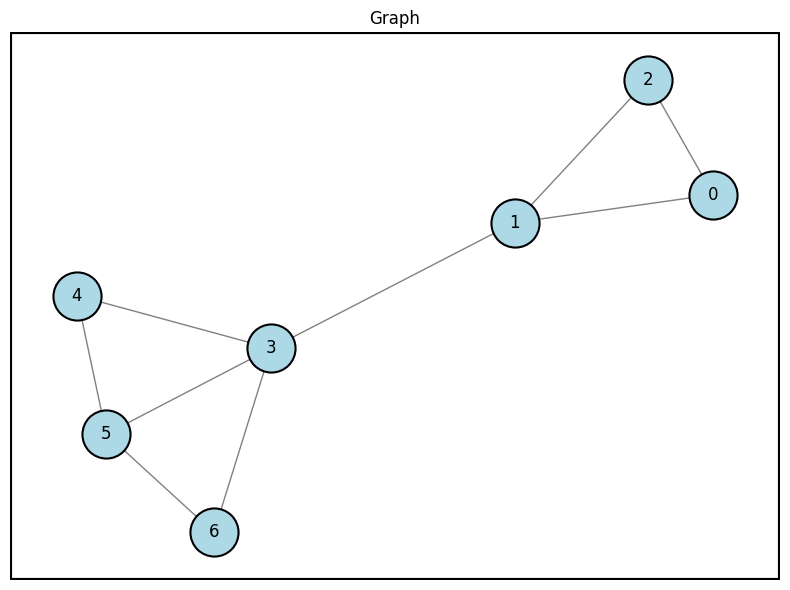

In [ ]:
G = graph_to_networkx(g)
visualize_graph(G)

> Initialize the Table

In [ ]:
image_list = []
df = init_table(g)
df

,0,1,2,3,4,5,6,sum,sum_by_half
0–1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0–2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1–2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1–3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3–4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3–5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3–6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4–5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5–6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> For every node as root, build the DAG and compute the edge values and update the table.


                       Root: 0
----------------------------------------------------------------------
       0    1    2    3    4    5    6  sum  sum_by_half
0–1  5.0  NaN  NaN  NaN  NaN  NaN  NaN  5.0          2.5
0–2  1.0  NaN  NaN  NaN  NaN  NaN  NaN  1.0          0.5
1–2  NaN  NaN  NaN  NaN  NaN  NaN  NaN  0.0          0.0
1–3  4.0  NaN  NaN  NaN  NaN  NaN  NaN  4.0          2.0
3–4  1.0  NaN  NaN  NaN  NaN  NaN  NaN  1.0          0.5
3–5  1.0  NaN  NaN  NaN  NaN  NaN  NaN  1.0          0.5
3–6  1.0  NaN  NaN  NaN  NaN  NaN  NaN  1.0          0.5
4–5  NaN  NaN  NaN  NaN  NaN  NaN  NaN  0.0          0.0
5–6  NaN  NaN  NaN  NaN  NaN  NaN  NaN  0.0          0.0


                       Root: 1
----------------------------------------------------------------------
       0    1    2    3    4    5    6  sum  sum_by_half
0–1  5.0  1.0  NaN  NaN  NaN  NaN  NaN  6.0          3.0
0–2  1.0  NaN  NaN  NaN  NaN  NaN  NaN  1.0          0.5
1–2  NaN  1.0  NaN  NaN  NaN  NaN  NaN  1.0         

/tmp/ipython-input-1927500444.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 7))



                       Root: 6
----------------------------------------------------------------------
       0    1    2    3    4    5    6   sum  sum_by_half
0–1  5.0  1.0  NaN  1.0  1.0  1.0  1.0  10.0          5.0
0–2  1.0  NaN  1.0  NaN  NaN  NaN  NaN   2.0          1.0
1–2  NaN  1.0  5.0  1.0  1.0  1.0  1.0  10.0          5.0
1–3  4.0  4.0  4.0  3.0  3.0  3.0  3.0  24.0         12.0
3–4  1.0  1.0  1.0  1.0  4.5  NaN  0.5   9.0          4.5
3–5  1.0  1.0  1.0  1.0  NaN  4.0  NaN   8.0          4.0
3–6  1.0  1.0  1.0  1.0  0.5  NaN  4.5   9.0          4.5
4–5  NaN  NaN  NaN  NaN  1.5  1.0  0.5   3.0          1.5
5–6  NaN  NaN  NaN  NaN  0.5  1.0  1.5   3.0          1.5



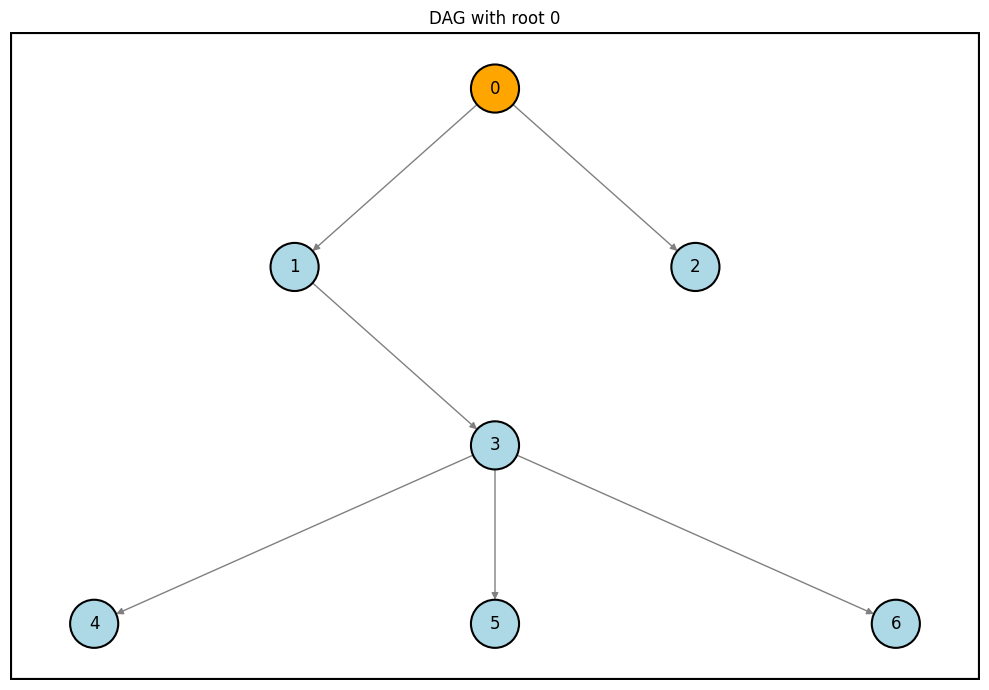

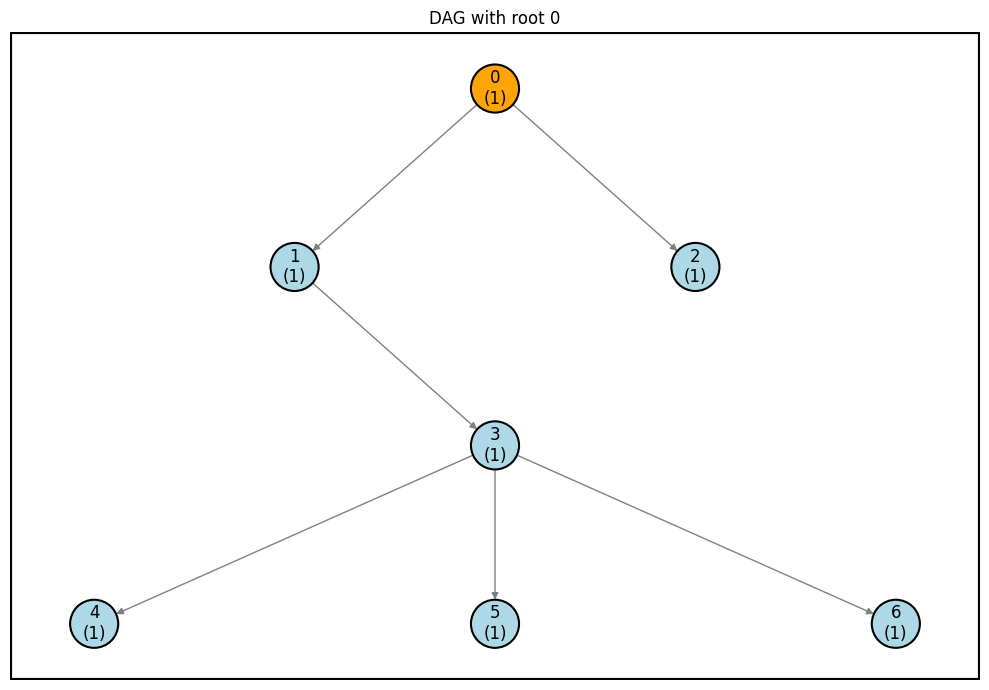

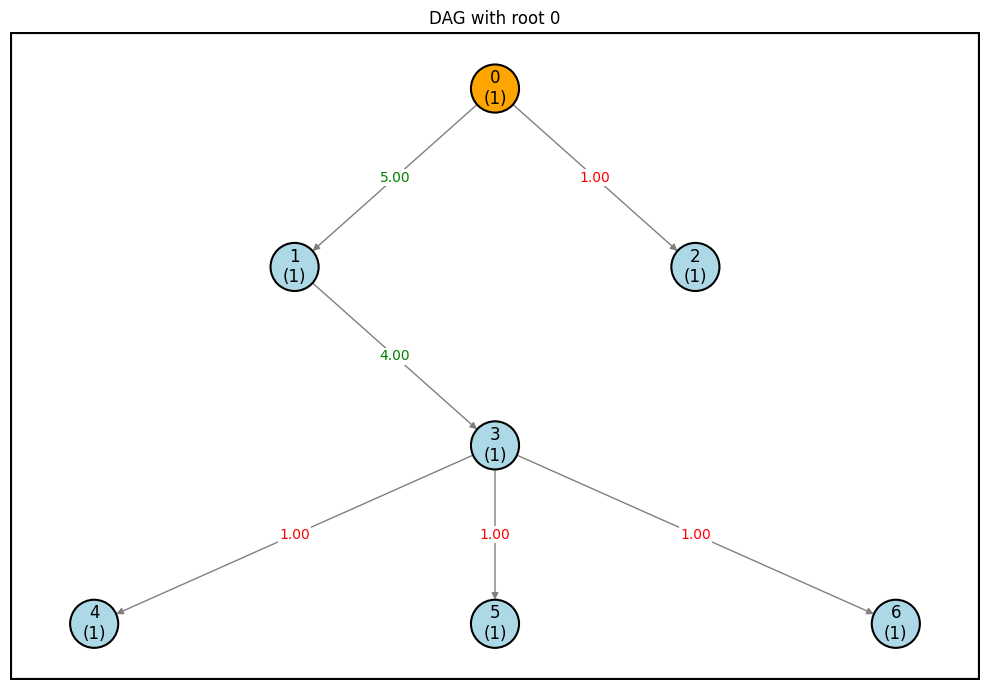

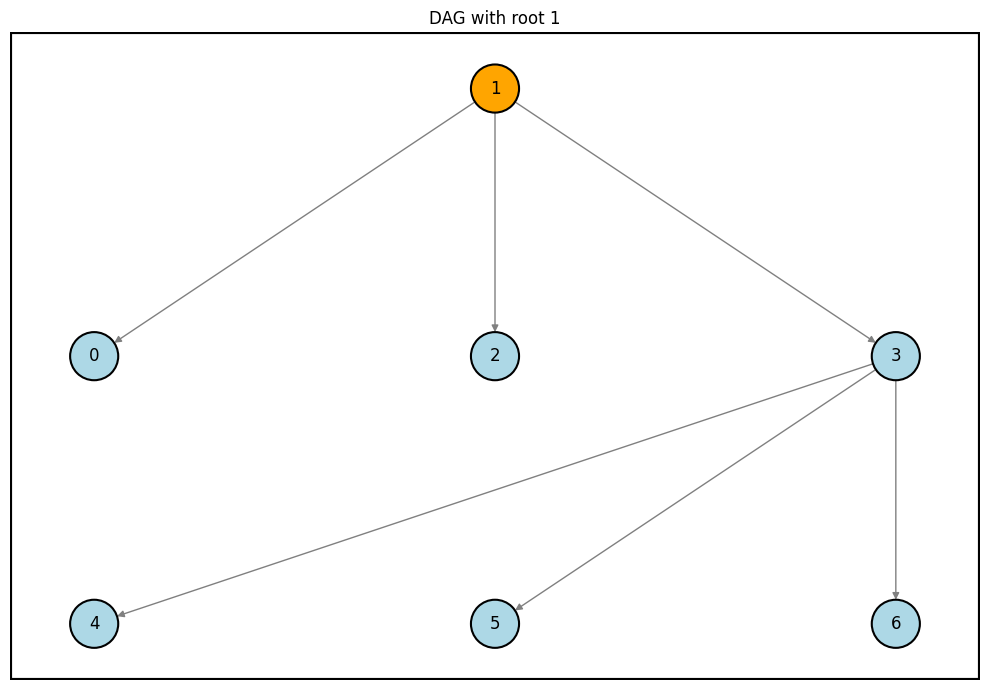

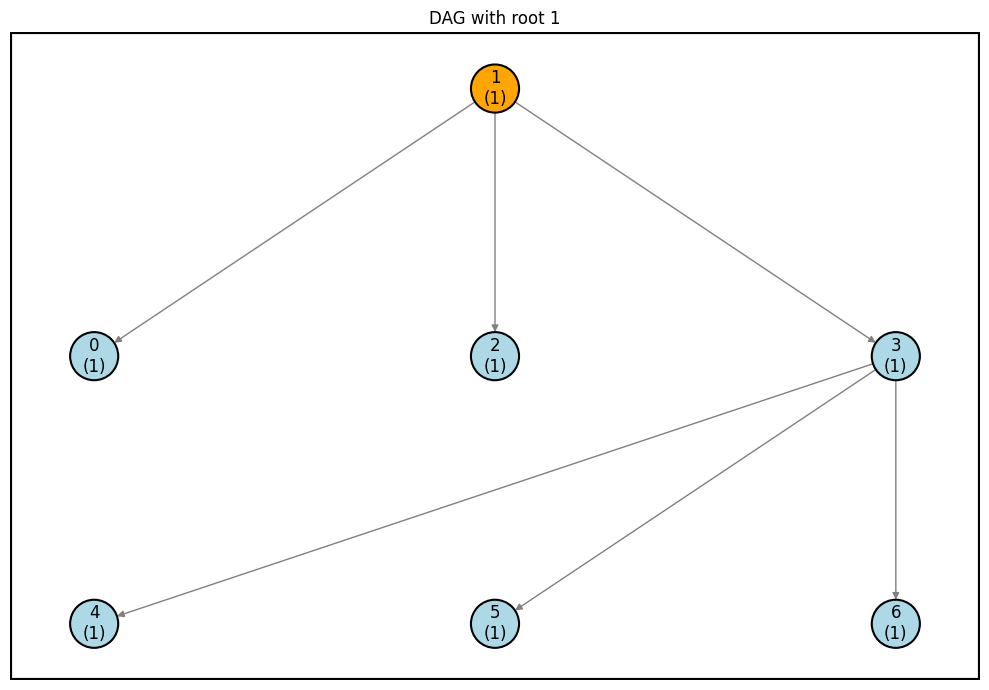

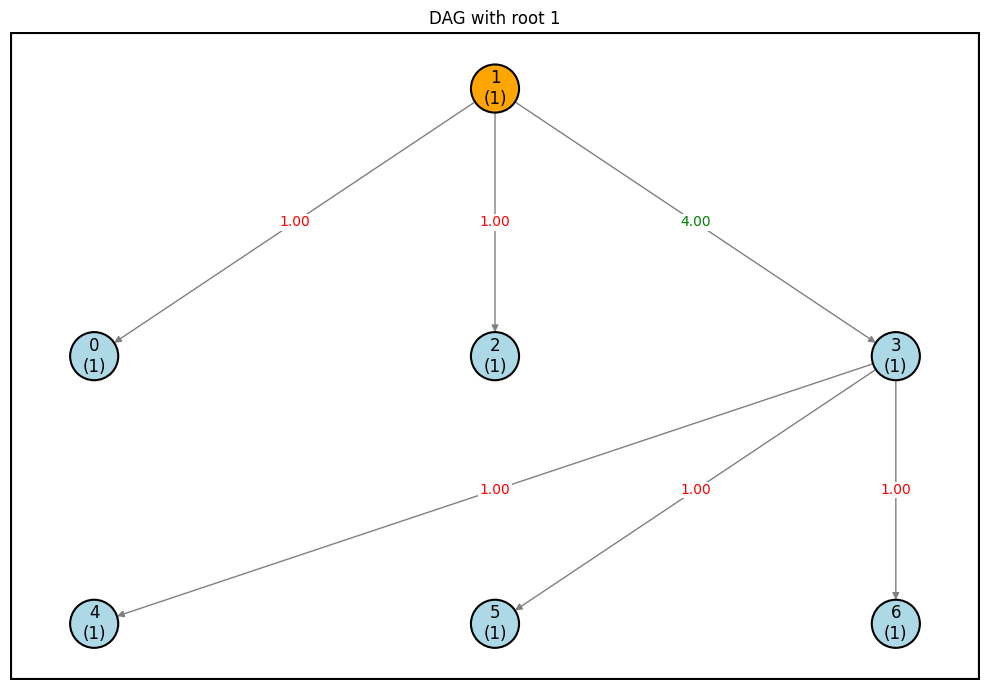

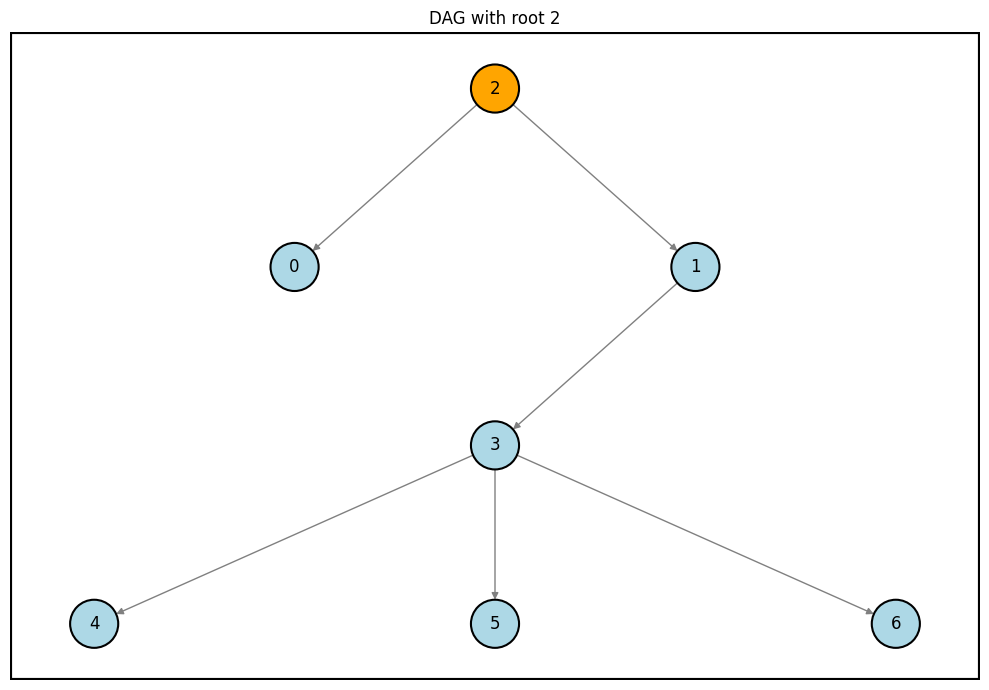

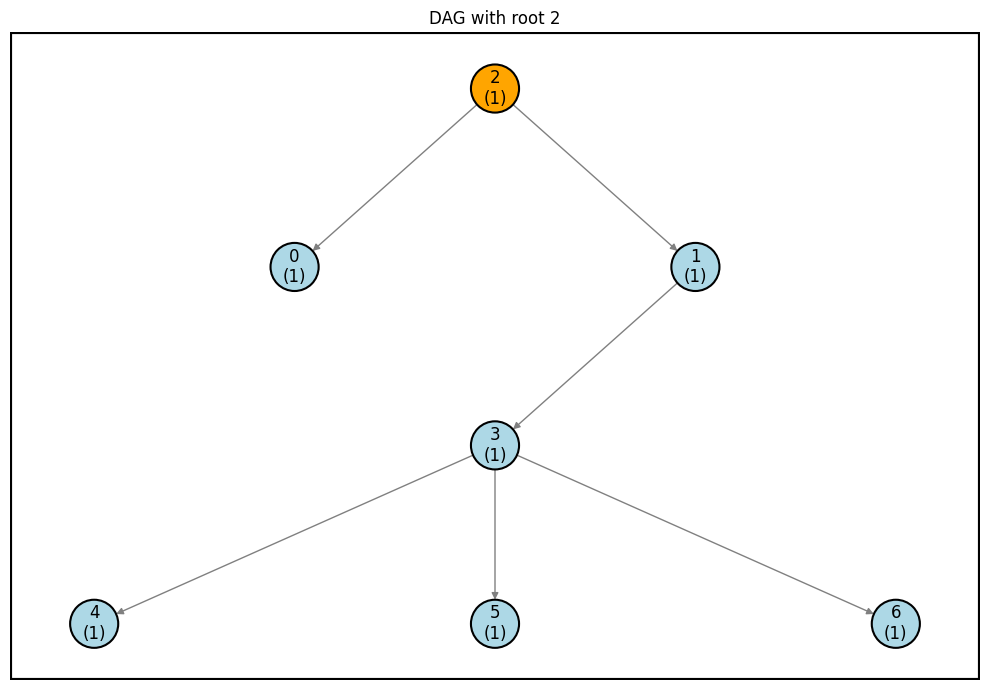

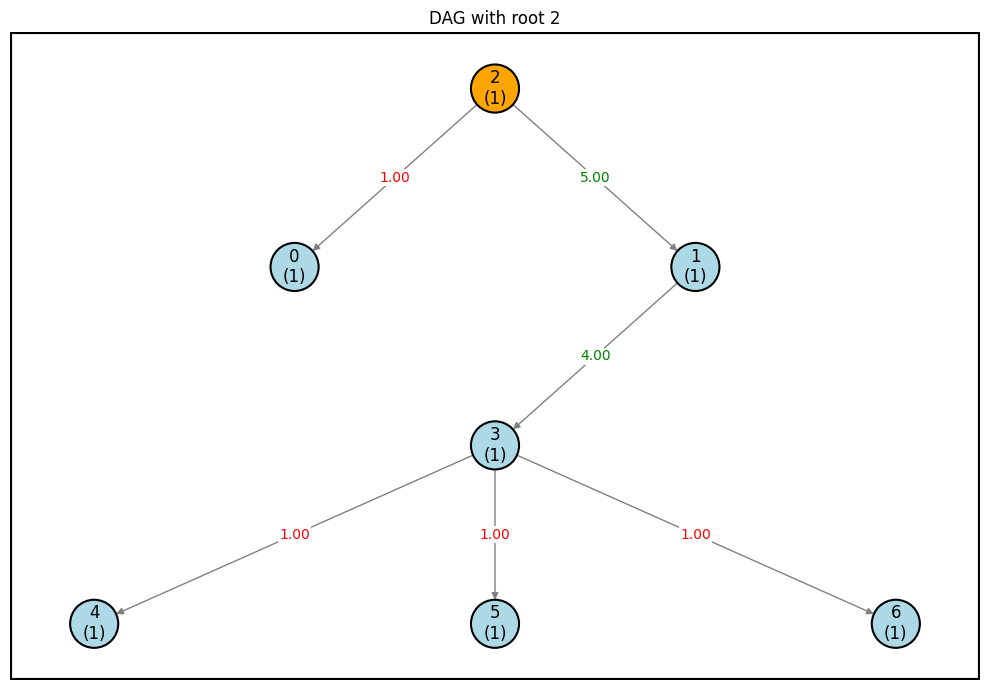

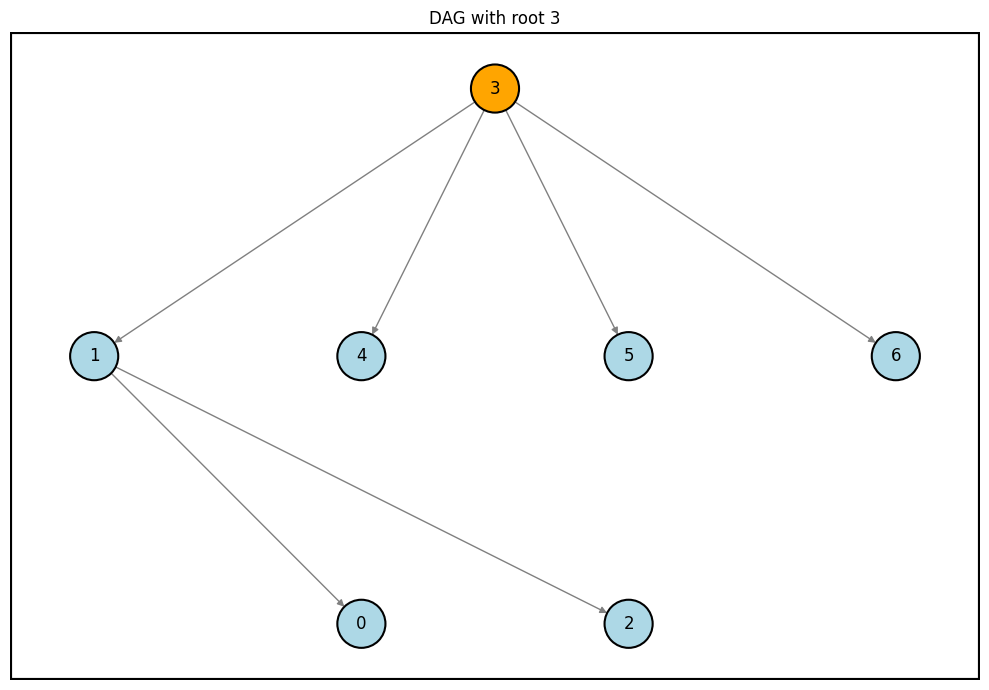

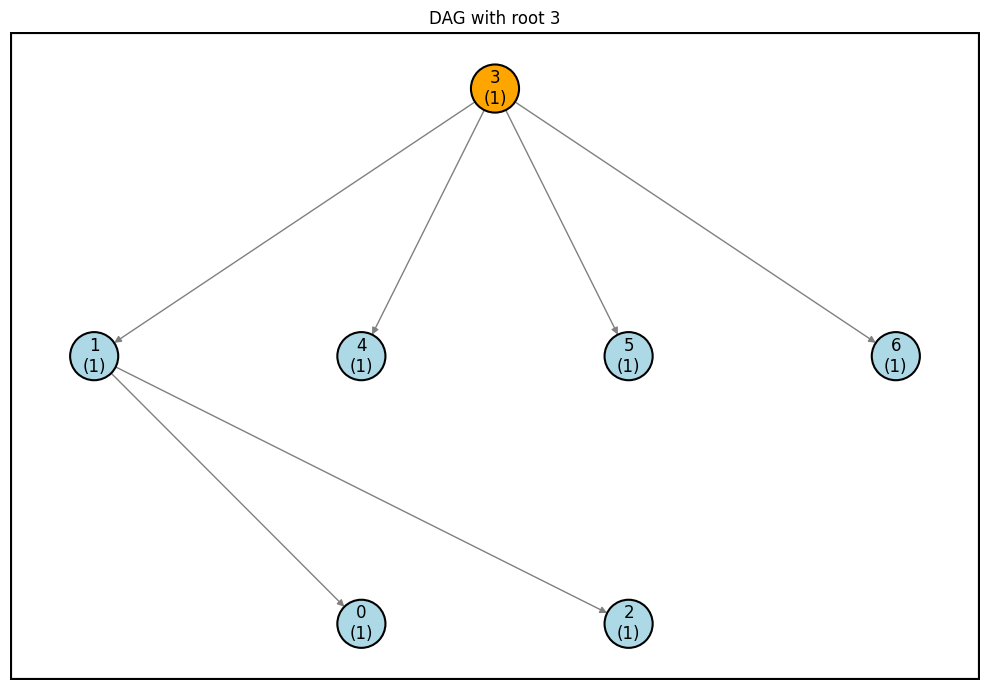

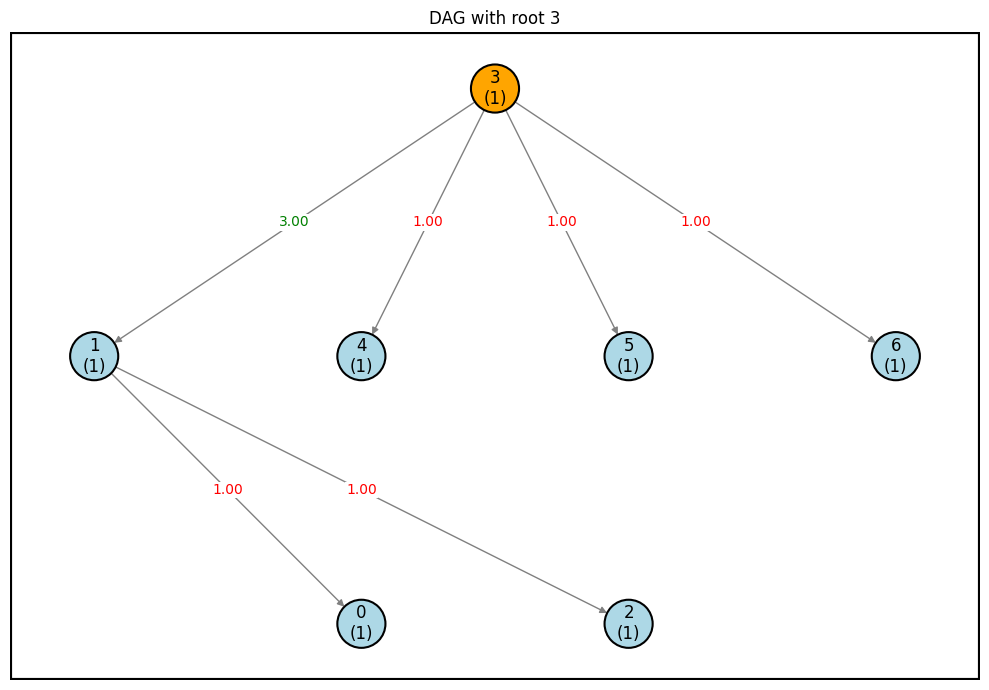

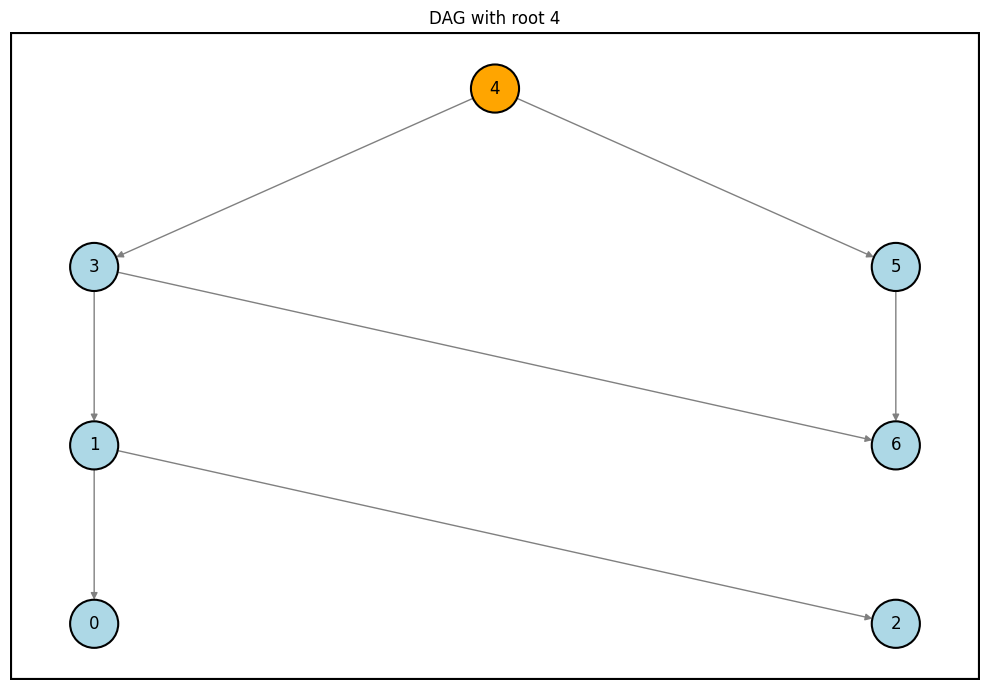

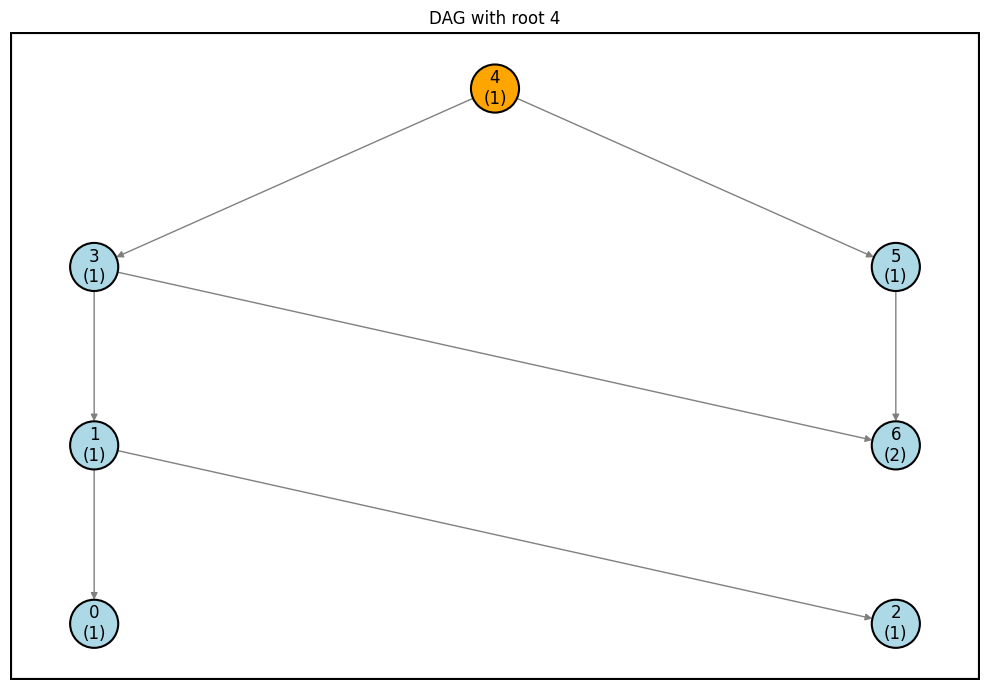

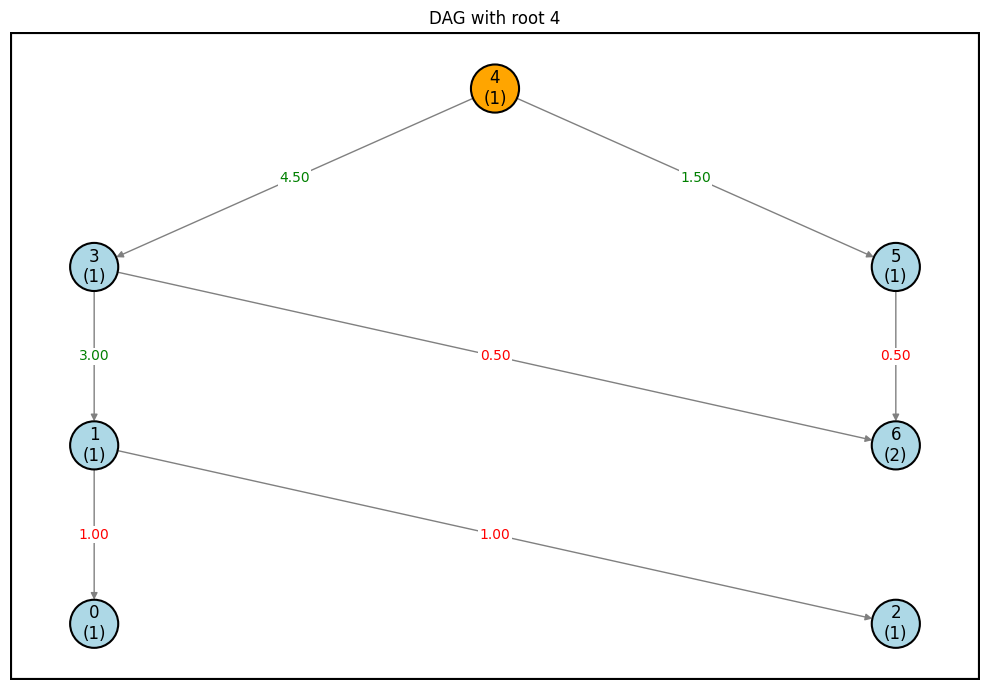

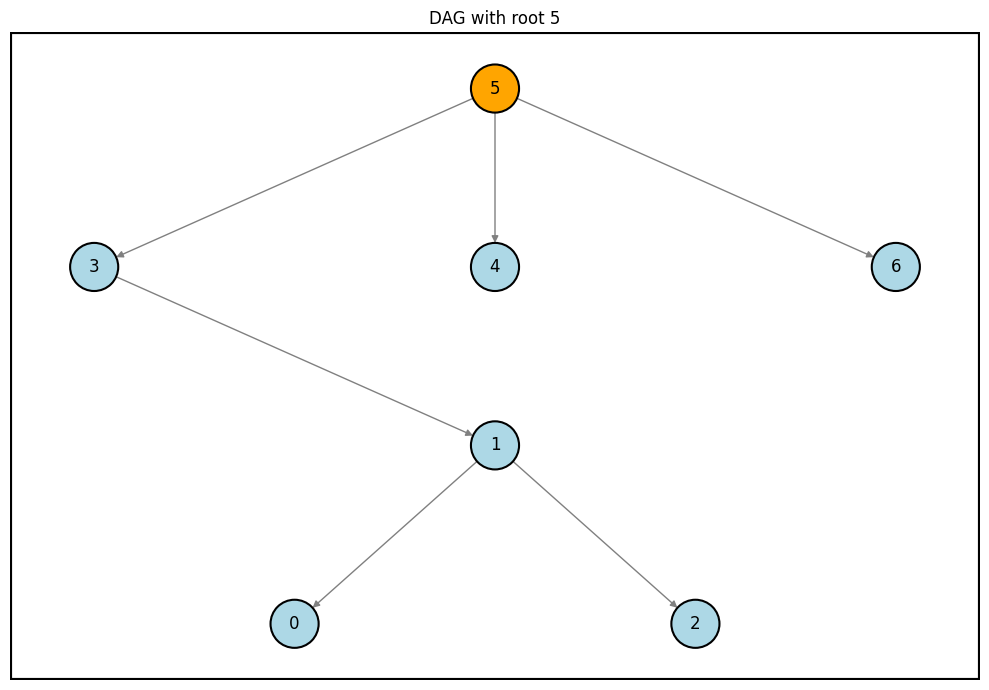

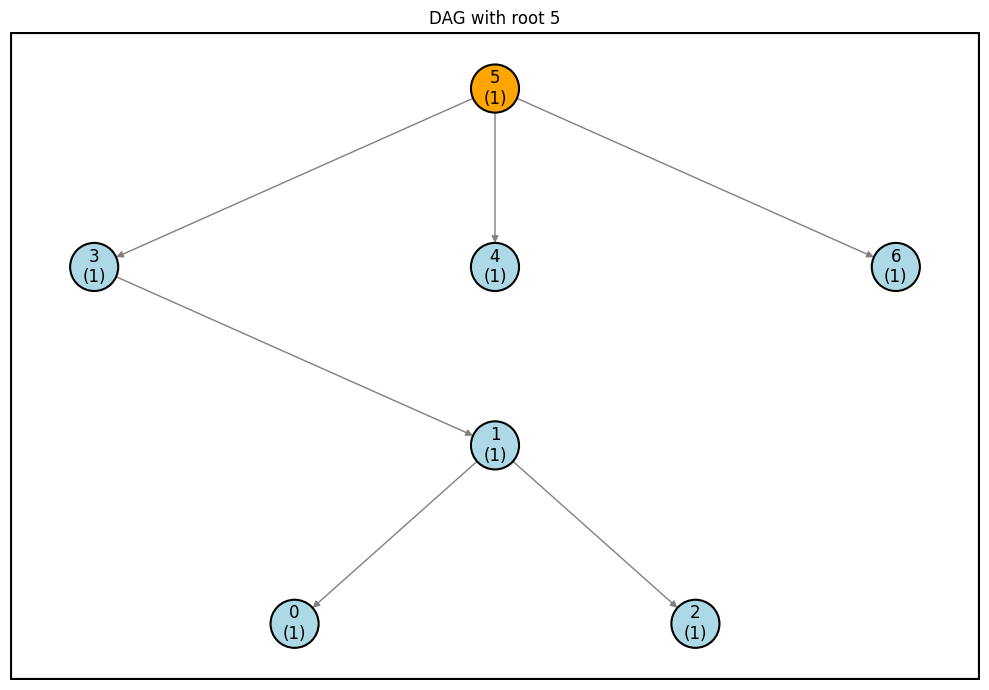

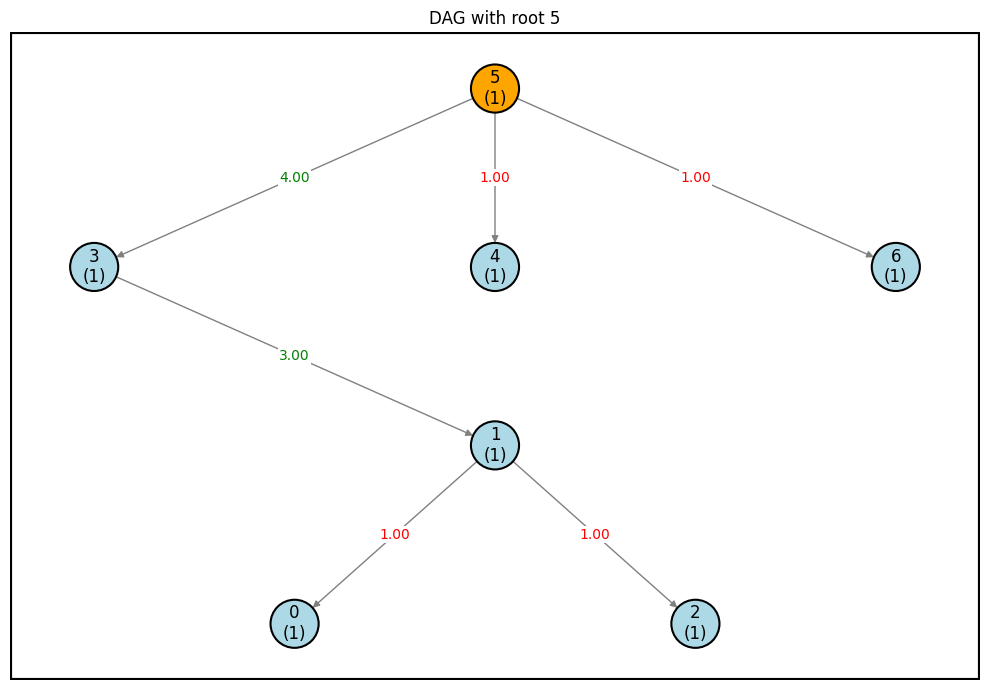

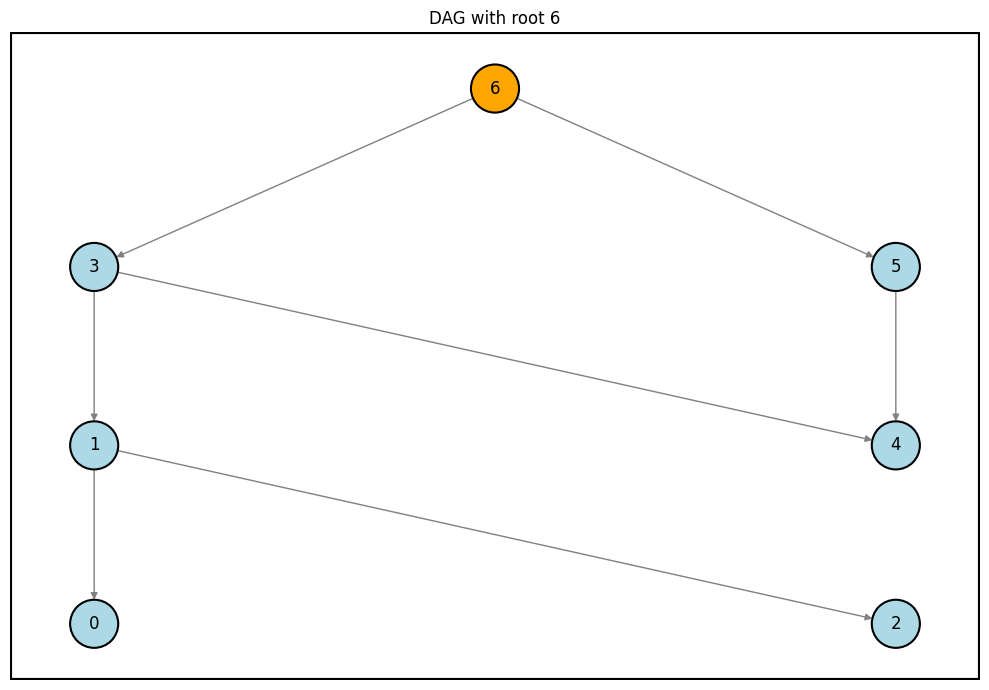

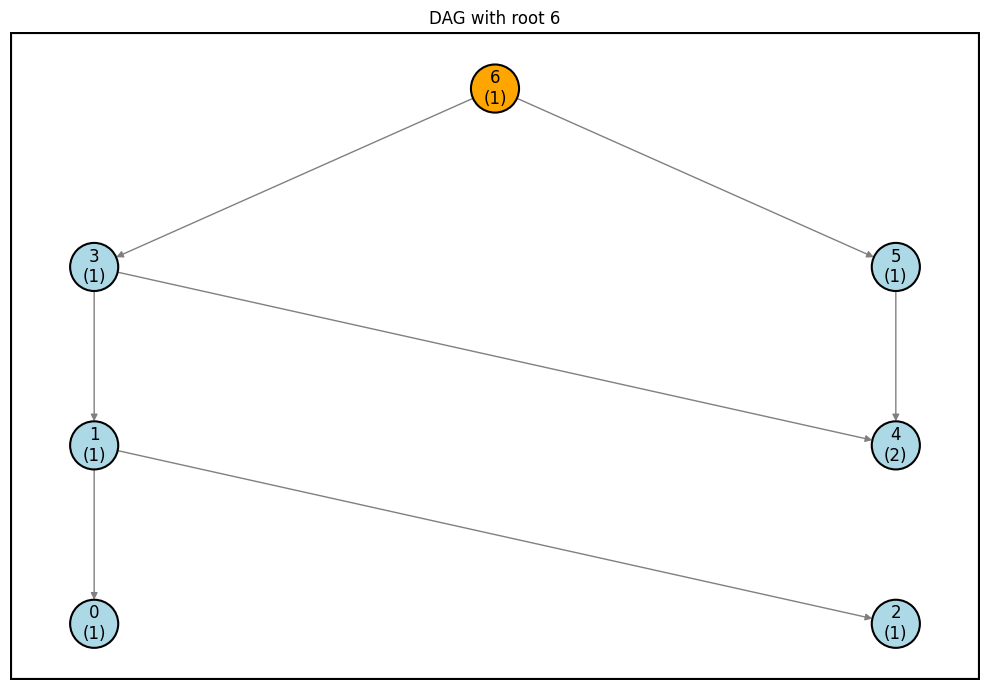

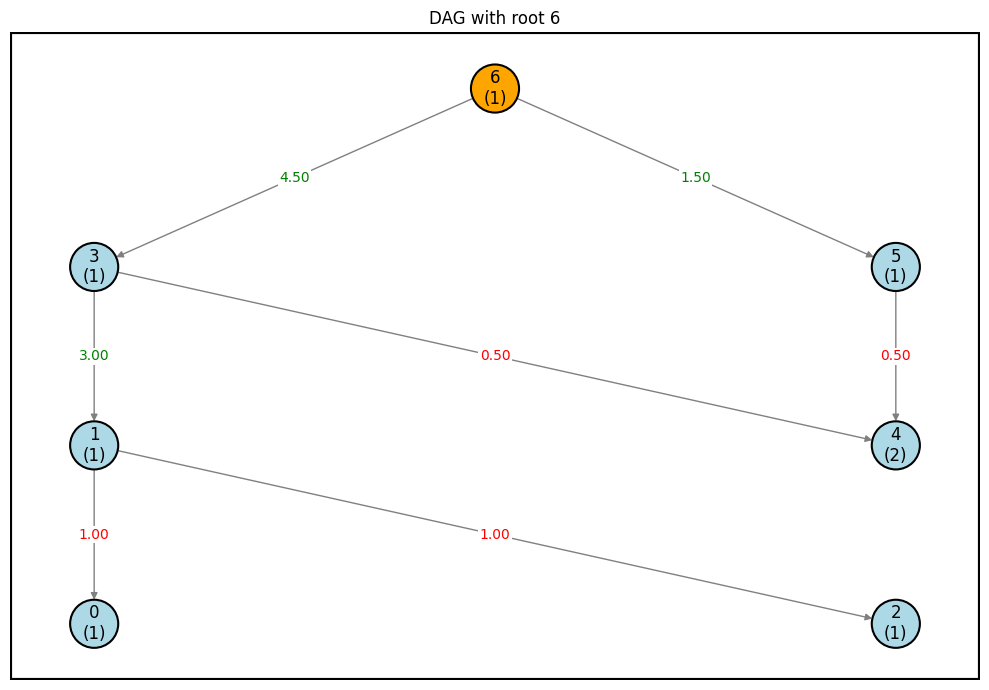

In [ ]:
for root_ in range(0,len(g)):
  #print(root_)
  dag = build_level_dag_with_props(g,root=root_)
  dag,edge_info = compute_edge_and_node_values(dag)
  fill_edge_values(df, root_, edge_info)
  x1 = visualize_dag(dag, root=root_, show_startoff=False, show_edge_value=False)
  x2 = visualize_dag(dag, root=root_, show_startoff=True, show_edge_value=False)
  x3 = visualize_dag(dag, root=root_, show_startoff=True, show_edge_value=True)
  i1 = figure_to_image(x1)
  i2 = figure_to_image(x2)
  i3 = figure_to_image(x3)
  image_list.append(i1)
  image_list.append(i2)
  image_list.append(i3)
  print()
  print(f"                       Root: {root_}")
  print("----------------------------------------------------------------------")
  print(df)
  print()

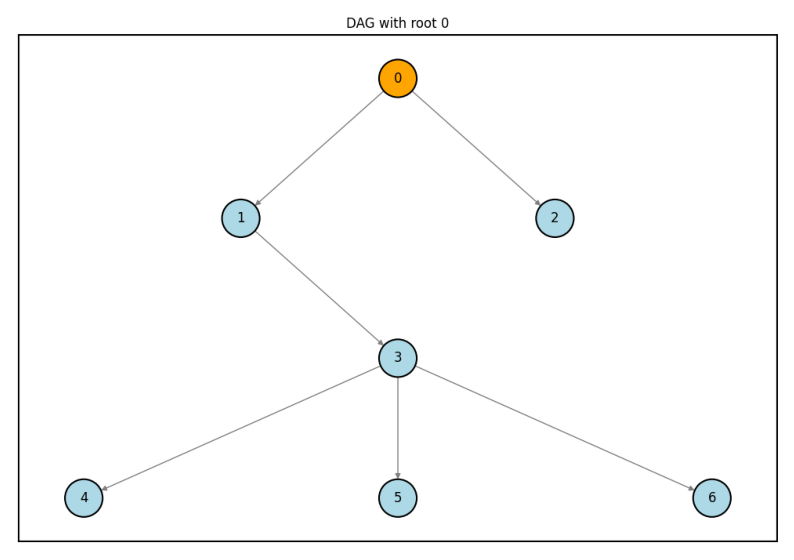

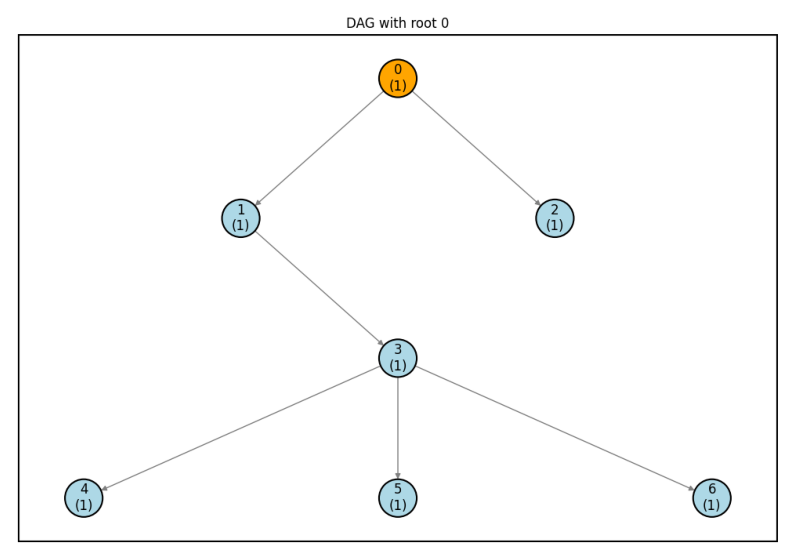

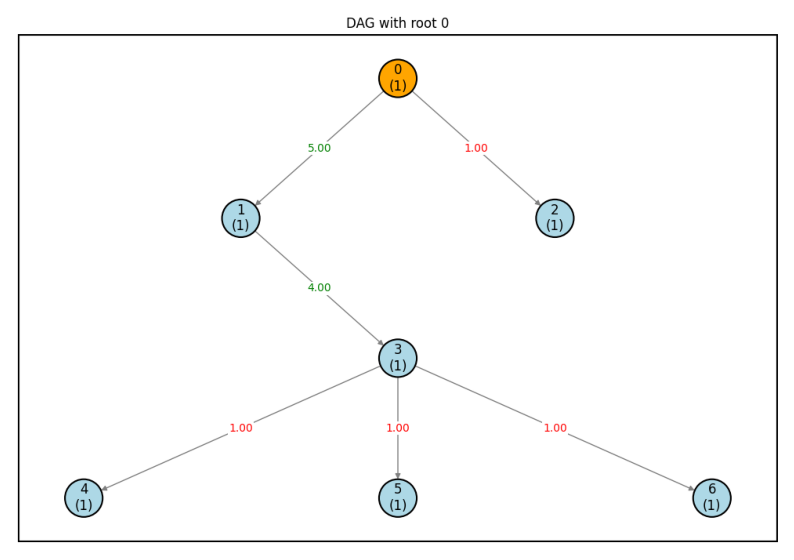

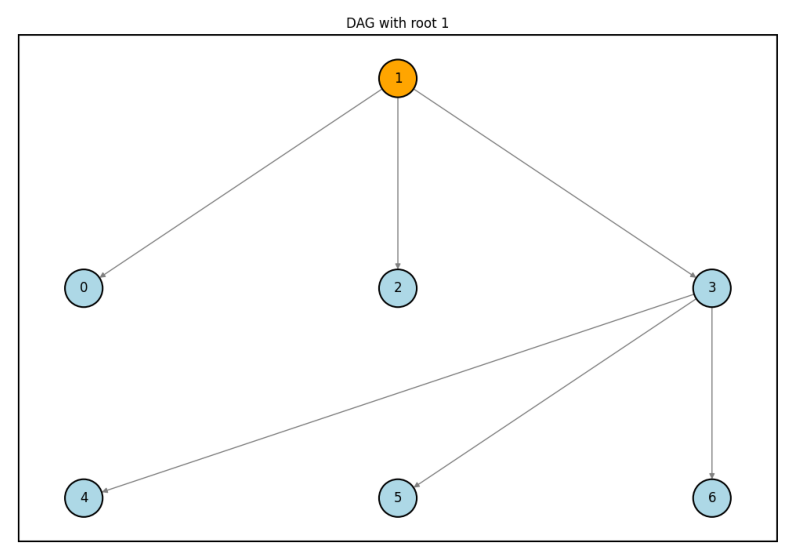

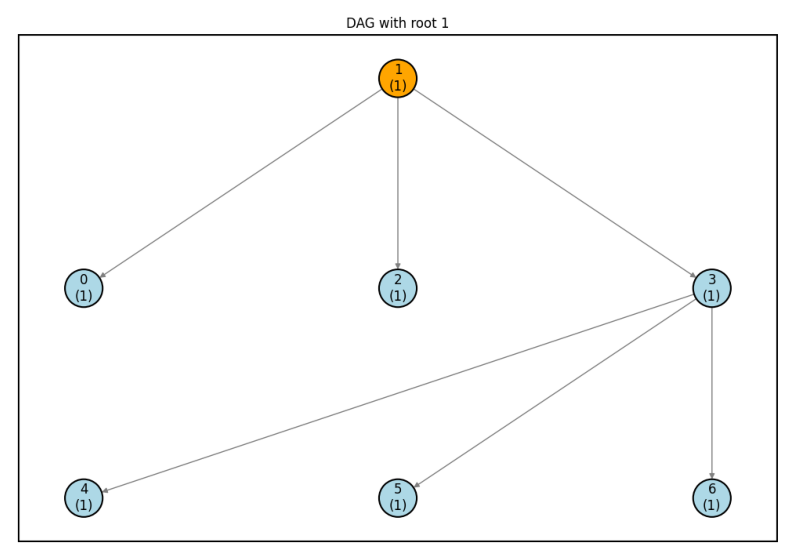

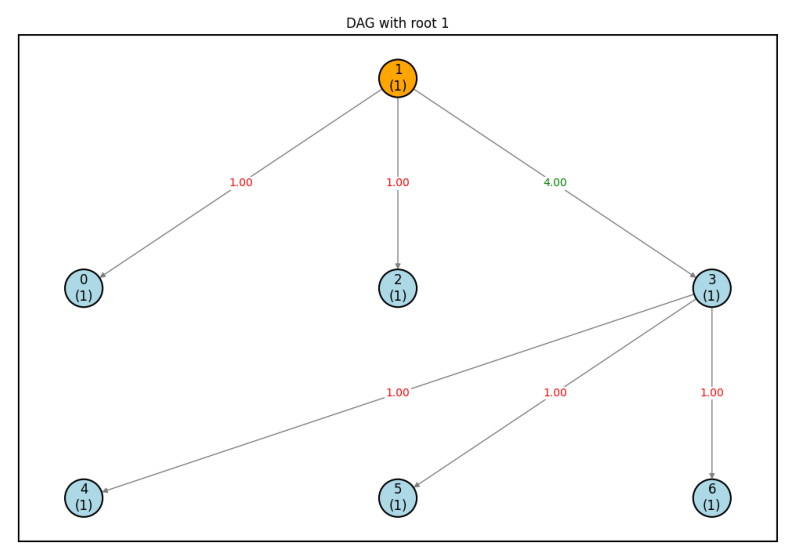

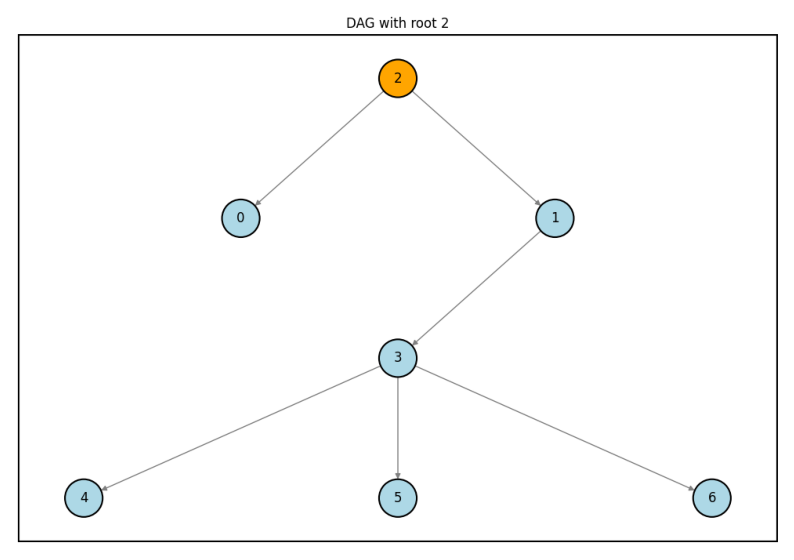

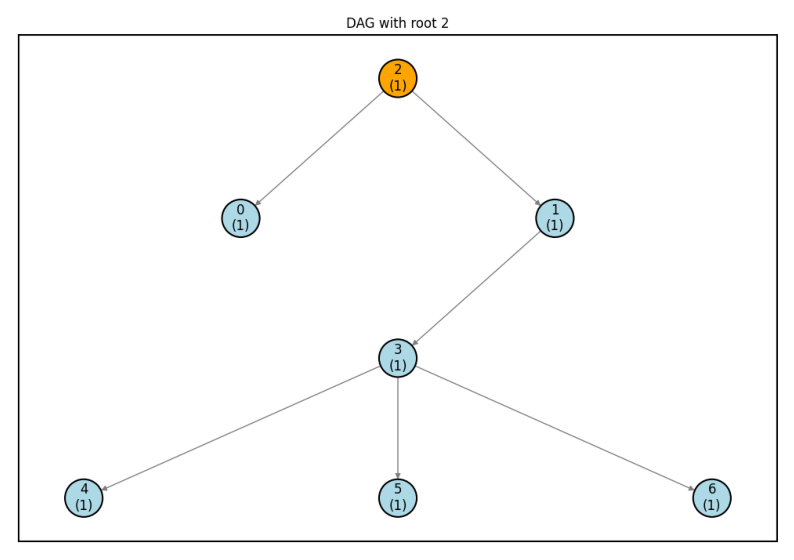

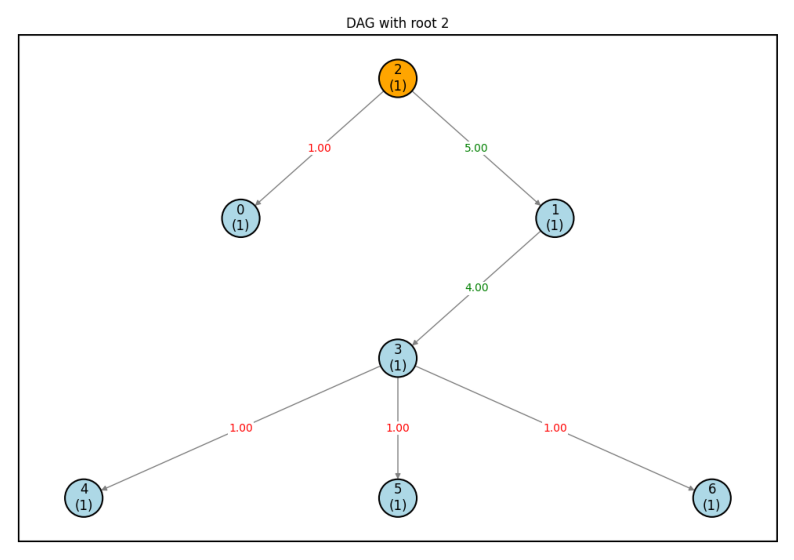

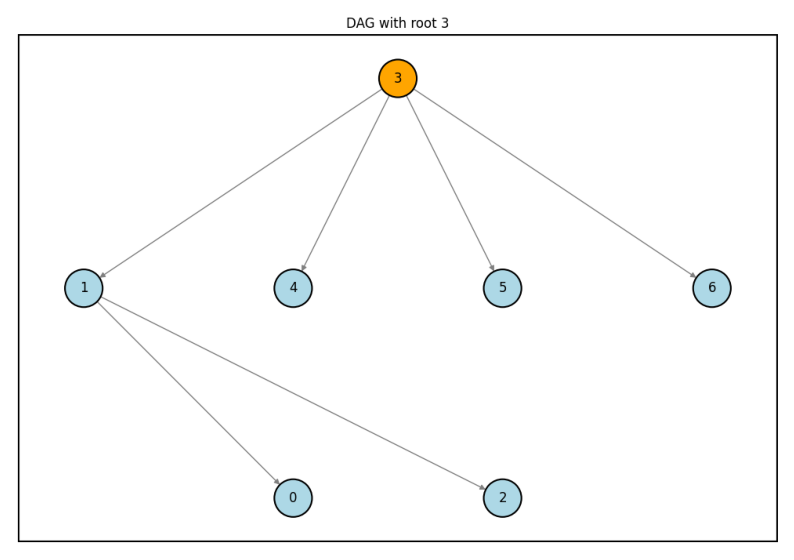

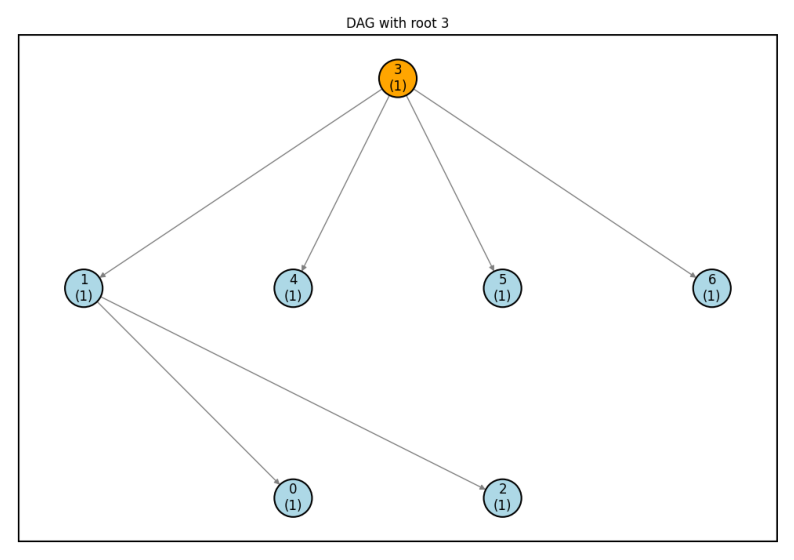

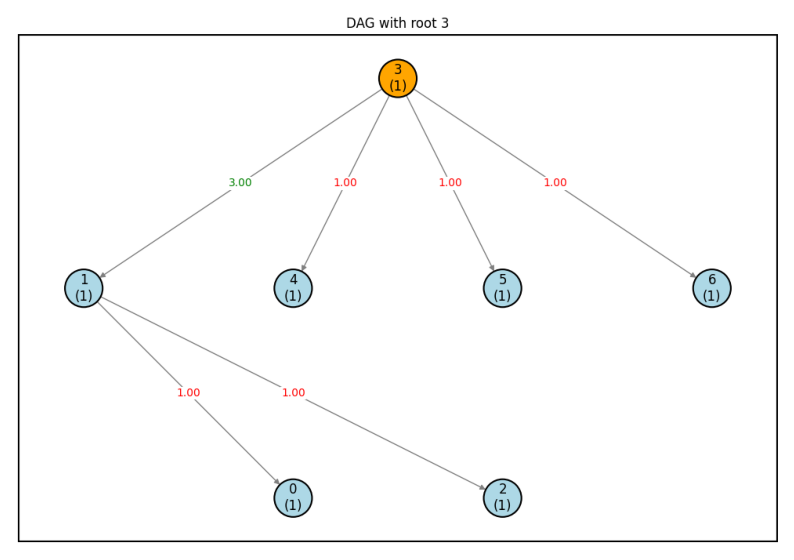

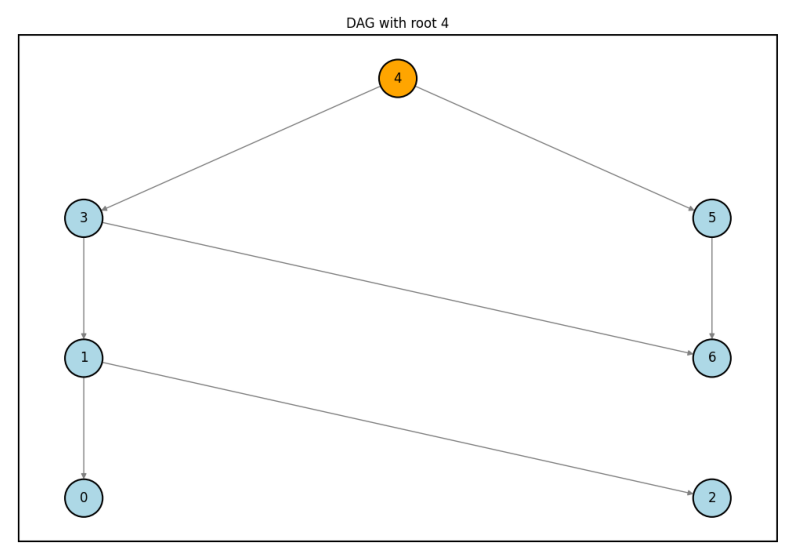

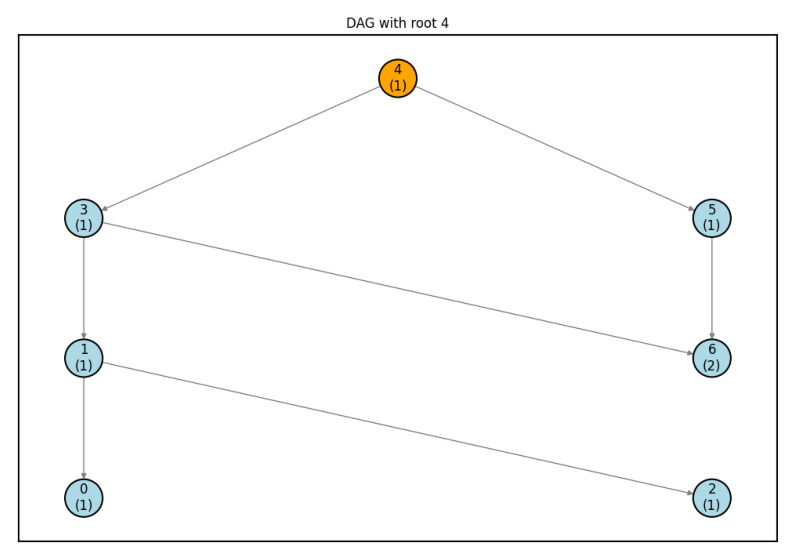

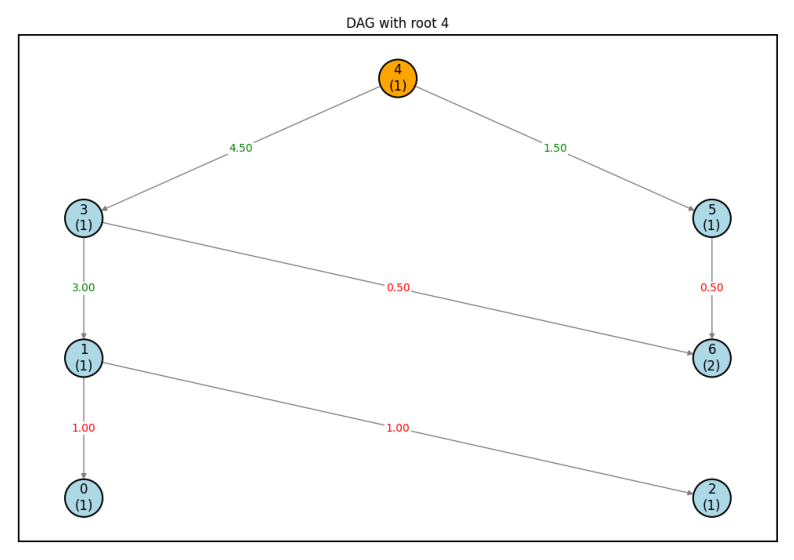

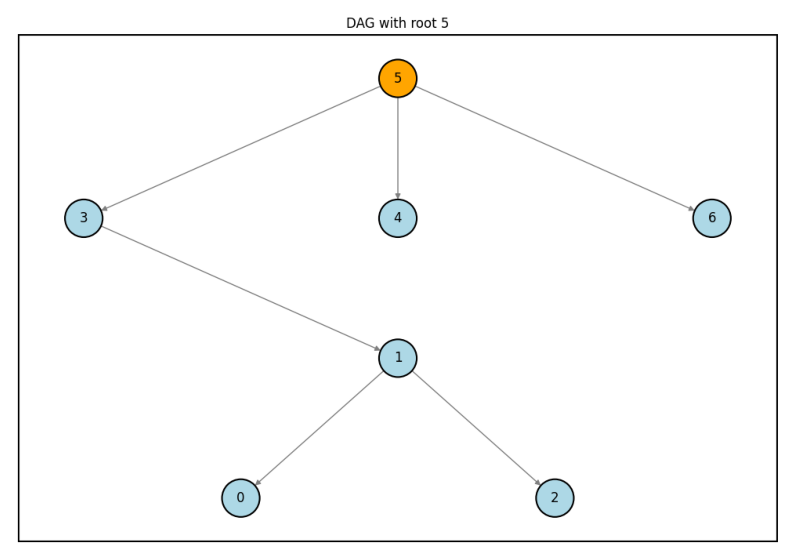

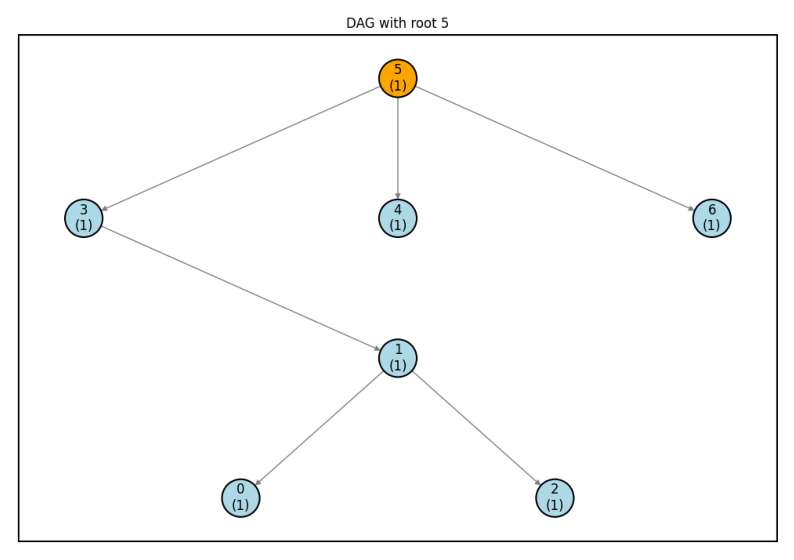

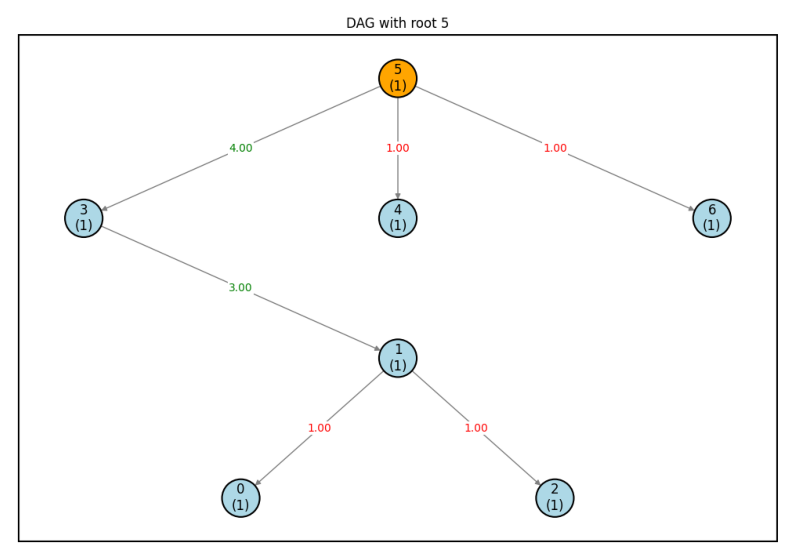

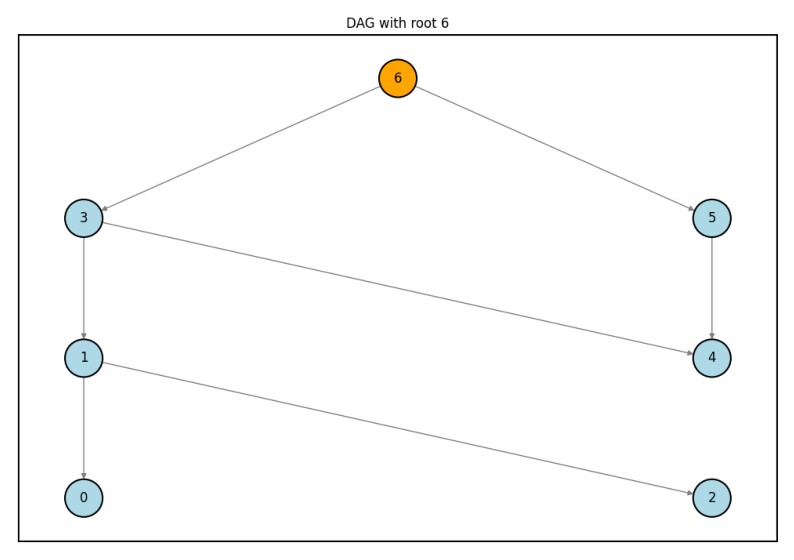

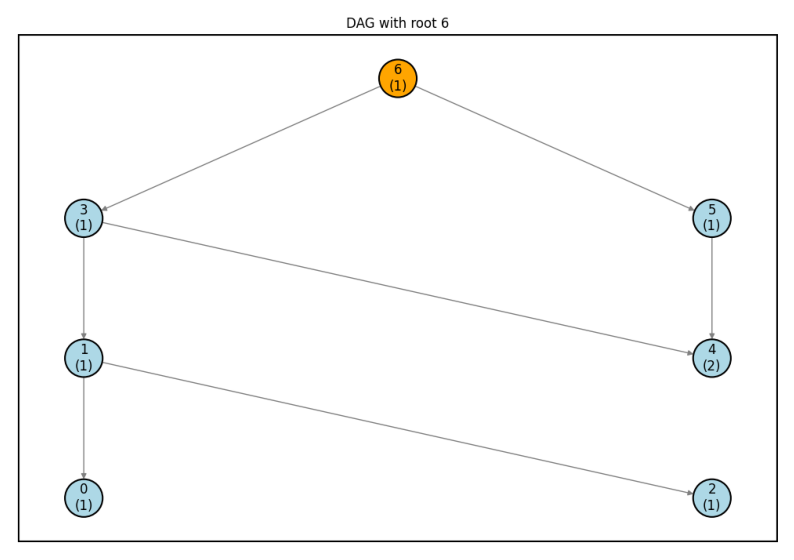

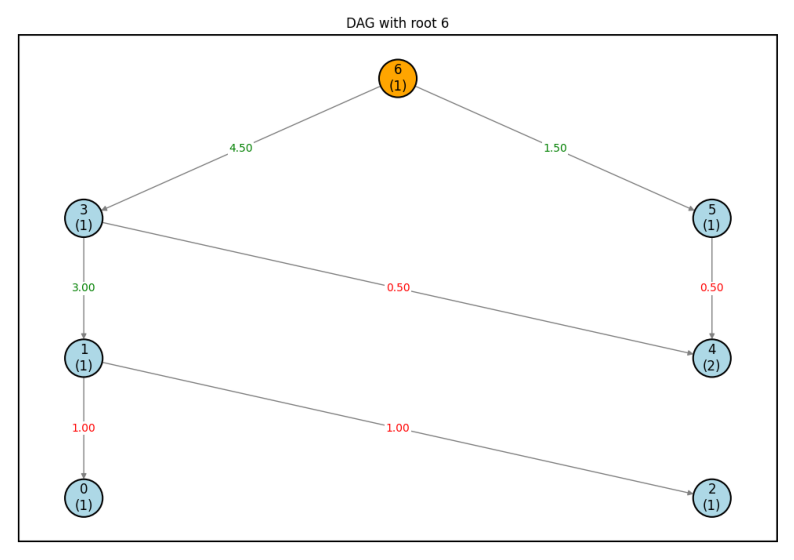

In [ ]:
for idx, img in enumerate(image_list, 1):
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

> Final Table

In [ ]:
df

,0,1,2,3,4,5,6,sum,sum_by_half
0–1,5.0,1.0,NaN,1.0,1.0,1.0,1.0,10.0,5.0
0–2,1.0,NaN,1.0,NaN,NaN,NaN,NaN,2.0,1.0
1–2,NaN,1.0,5.0,1.0,1.0,1.0,1.0,10.0,5.0
1–3,4.0,4.0,4.0,3.0,3.0,3.0,3.0,24.0,12.0
3–4,1.0,1.0,1.0,1.0,4.5,NaN,0.5,9.0,4.5
3–5,1.0,1.0,1.0,1.0,NaN,4.0,NaN,8.0,4.0
3–6,1.0,1.0,1.0,1.0,0.5,NaN,4.5,9.0,4.5
4–5,NaN,NaN,NaN,NaN,1.5,1.0,0.5,3.0,1.5
5–6,NaN,NaN,NaN,NaN,0.5,1.0,1.5,3.0,1.5


In [ ]:
df_summary = df[['sum_by_half']]
df_summary

,sum_by_half
0–1,5.0
0–2,1.0
1–2,5.0
1–3,12.0
3–4,4.5
3–5,4.0
3–6,4.5
4–5,1.5
5–6,1.5


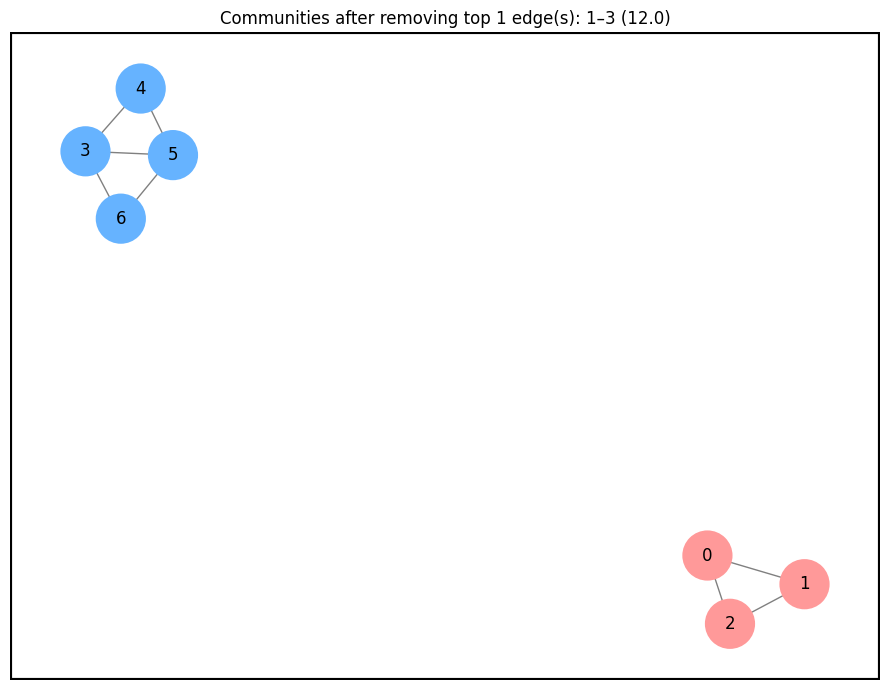

In [ ]:
sum_by_half_data = df['sum_by_half'].to_dict()
visualize_communities_by_edge_removal(sum_by_half_data, num_edges_to_remove=1)